# EEG_08c — EEG-First Subject Clustering

Approccio: **prima cluster, poi accuracy** (indicazione Francesco, 07-mag-2026).

Non usare accuracy come segnale primario — la varianza e' troppo bassa per separare soggetti.
Invece: clusterizzare soggetti da feature EEG grezze, poi verificare se accuracy si allinea ai cluster.

| Step | Cosa |
|------|------|
| **§2** | Estrazione feature EEG per soggetto (band power, degree, ISC) |
| **§3** | Build matrice feature soggetti (N_subj x D_feat) |
| **§4** | PCA + scelta dimensionalita' |
| **§5** | Clustering KMeans k=2,3 + Silhouette + Elbow |
| **§6** | Clustering gerarchico (dendrogram) |
| **§7** | t-SNE / UMAP 2D — visualizzazione cluster |
| **§8** | Post-hoc: overlay EEG_08b accuracy — validazione cluster |
| **§9** | Test statistico cluster vs accuracy (Kruskal-Wallis) |


In [ ]:
import json
import logging
import re
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import torch
from scipy import signal as scipy_signal
from scipy.stats import pearsonr, spearmanr, kruskal
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s  %(levelname)-8s  %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg08c')

project_root = next(
    (p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / '.git').exists()),
    Path.cwd(),
)
FIG_DIR = project_root / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# ---- config ----
SFREQ      = 256
N_CHANNELS = 61
CSV_ROOT   = project_root / 'data' / 'raw_csv' / 'training_set'
PT_ROOT    = project_root / 'data' / 'graphs_abs_pcc'   # EEG_07f output (abs_pcc)
MAX_TRIALS_PER_SESSION = 30   # cap per velocita'

BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

_PAT = re.compile(r'^P(\d+)_S(\d+)$')

# --- raccolta path per soggetto -> sessione ---
subj_sess_pts = defaultdict(lambda: defaultdict(list))
for p in sorted(PT_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess_pts[int(m.group(1))][int(m.group(2))].append(p)

subj_sess_csv = defaultdict(lambda: defaultdict(list))
for sess_dir in sorted(CSV_ROOT.iterdir()):
    m = _PAT.match(sess_dir.name)
    if m:
        subj_sess_csv[int(m.group(1))][int(m.group(2))].extend(
            sorted(sess_dir.glob('*_img.csv')))

ALL_SUBJ_IDS = sorted(set(subj_sess_pts.keys()) | set(subj_sess_csv.keys()))
log.info(f'Soggetti totali: {len(ALL_SUBJ_IDS)}')
log.info(f'  con PT: {len(subj_sess_pts)}  con CSV: {len(subj_sess_csv)}')


## §2 — Estrazione Feature EEG per Soggetto

Per ogni soggetto: band power per canale (da CSV), mean node degree (da PT), ISC.

In [ ]:
# ---- Band Power per canale ----
def bandpower_trial_per_ch(x, sfreq, fmin, fmax):
    """Band power per canale per un trial. x: (61, T). Returns (61,)."""
    nperseg = min(256, x.shape[1])
    freqs, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg, axis=1)  # (61, F)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return psd[:, idx].mean(axis=1)   # (61,)

def subject_bandpower_features(subj_id):
    """
    Restituisce feature band power: (5_bande x 61_canali,) = 305-dim.
    Media su sessioni e trial disponibili.
    """
    all_bp = defaultdict(list)  # band -> list of (61,)
    for sess_id, paths in subj_sess_csv[subj_id].items():
        for p in paths[:MAX_TRIALS_PER_SESSION]:
            try:
                x = pd.read_csv(p, header=None).values.astype(np.float32)
                if x.shape != (N_CHANNELS, 384):
                    continue
                for band, (fmin, fmax) in BANDS.items():
                    all_bp[band].append(bandpower_trial_per_ch(x, SFREQ, fmin, fmax))
            except Exception:
                continue

    feat = []
    for band in BANDS:
        vecs = all_bp[band]
        if vecs:
            feat.append(np.mean(vecs, axis=0))   # (61,)
        else:
            feat.append(np.zeros(N_CHANNELS))
    return np.concatenate(feat)   # (305,)


# ---- Mean Node Degree da PT ----
def subject_degree_features(subj_id):
    """
    Degree medio per nodo: (61,).
    Usa la adj assoluta media su tutti i trial del soggetto.
    """
    adjs = []
    for sess_id, paths in subj_sess_pts[subj_id].items():
        for p in paths[:MAX_TRIALS_PER_SESSION]:
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj']
                if isinstance(adj, torch.Tensor):
                    adj = adj.numpy()
                adjs.append(np.abs(adj))
            except Exception:
                continue
    if not adjs:
        return np.zeros(N_CHANNELS)
    mean_adj = np.mean(adjs, axis=0)   # (61, 61)
    return mean_adj.sum(axis=1)        # (61,) degree per nodo


# ---- Inter-Session Consistency (scalar) ----
def subject_isc(subj_id):
    """Pearson r medio tra mean adj di sessioni diverse. Scalar."""
    sess = subj_sess_pts[subj_id]
    sids = sorted(sess.keys())
    if len(sids) < 2:
        return np.nan
    means = []
    for s in sids:
        adjs = []
        for p in sess[s][:MAX_TRIALS_PER_SESSION]:
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj']
                if isinstance(adj, torch.Tensor):
                    adj = adj.numpy()
                adjs.append(adj)
            except Exception:
                continue
        if adjs:
            means.append(np.mean(adjs, axis=0))
    if len(means) < 2:
        return np.nan
    corrs = []
    for a, b in combinations(means, 2):
        idx = np.triu_indices(a.shape[0], k=1)
        r, _ = pearsonr(a[idx], b[idx])
        corrs.append(r)
    return float(np.mean(corrs))


## §3 — Build Matrice Feature Soggetti

Richiede ~10-20 min (lettura CSV + PT).  
Se gia' fatto: carica da cache.

In [ ]:
CACHE_PATH = FIG_DIR / 'eeg08c_subject_features.npz'

if CACHE_PATH.exists():
    log.info(f'Carico feature da cache: {CACHE_PATH}')
    cache = np.load(CACHE_PATH, allow_pickle=True)
    SUBJ_IDS   = cache['subj_ids'].tolist()
    FEAT_MATRIX = cache['feat_matrix']
    FEAT_NAMES  = cache['feat_names'].tolist()
    log.info(f'Feature matrix: {FEAT_MATRIX.shape}')
else:
    log.info('Estrazione feature (prima esecuzione, ~10-20 min)...')
    rows_bp  = []   # band power (305,)
    rows_deg = []   # degree (61,)
    rows_isc = []   # ISC scalar
    valid_ids = []

    for sid in tqdm(ALL_SUBJ_IDS, desc='Soggetti'):
        has_csv = bool(subj_sess_csv.get(sid))
        has_pt  = bool(subj_sess_pts.get(sid))

        bp  = subject_bandpower_features(sid) if has_csv else np.zeros(305)
        deg = subject_degree_features(sid)    if has_pt  else np.zeros(N_CHANNELS)
        isc = subject_isc(sid)                if has_pt  else np.nan

        if np.all(bp == 0) and np.all(deg == 0):
            log.warning(f'  P{sid:03d}: no data, skip')
            continue

        rows_bp.append(bp)
        rows_deg.append(deg)
        rows_isc.append(isc if not np.isnan(isc) else 0.0)
        valid_ids.append(sid)

    SUBJ_IDS    = valid_ids
    feat_bp     = np.stack(rows_bp,  axis=0)   # (N, 305)
    feat_deg    = np.stack(rows_deg, axis=0)   # (N, 61)
    feat_isc    = np.array(rows_isc).reshape(-1, 1)  # (N, 1)
    FEAT_MATRIX = np.concatenate([feat_bp, feat_deg, feat_isc], axis=1)  # (N, 367)

    # feature names
    FEAT_NAMES = []
    for band in BANDS:
        FEAT_NAMES += [f'bp_{band}_ch{i}' for i in range(N_CHANNELS)]
    FEAT_NAMES += [f'deg_ch{i}' for i in range(N_CHANNELS)]
    FEAT_NAMES += ['isc']

    np.savez(CACHE_PATH, subj_ids=np.array(SUBJ_IDS),
             feat_matrix=FEAT_MATRIX, feat_names=np.array(FEAT_NAMES))
    log.info(f'Feature matrix salvata: {FEAT_MATRIX.shape} -> {CACHE_PATH}')

N_SUBJ = len(SUBJ_IDS)
log.info(f'N_SUBJ={N_SUBJ}  N_FEAT={FEAT_MATRIX.shape[1]}')
print(f'Feature matrix: {FEAT_MATRIX.shape} — {N_SUBJ} soggetti × {FEAT_MATRIX.shape[1]} features')


## §4 — PCA + Scelta Dimensionalita'

Normalizza → PCA → retain 95% varianza.

In [ ]:
# Imputa NaN (safety) e normalizza
FEAT_CLEAN = np.nan_to_num(FEAT_MATRIX, nan=0.0)
scaler = StandardScaler()
FEAT_SCALED = scaler.fit_transform(FEAT_CLEAN)   # (N, 367)

# PCA
pca_full = PCA().fit(FEAT_SCALED)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int(np.searchsorted(cum_var, 0.95)) + 1
n_comp_90 = int(np.searchsorted(cum_var, 0.90)) + 1
log.info(f'PCA: {n_comp_90} comp -> 90% var, {n_comp_95} comp -> 95% var')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_var)+1), cum_var, lw=2)
ax.axhline(0.90, color='orange', ls='--', lw=1, label='90%')
ax.axhline(0.95, color='red',    ls='--', lw=1, label='95%')
ax.axvline(n_comp_90, color='orange', ls='--', lw=1)
ax.axvline(n_comp_95, color='red',    ls='--', lw=1)
ax.set_xlabel('N componenti PCA'); ax.set_ylabel('Varianza cumulativa')
ax.set_title('PCA — varianza cumulativa'); ax.legend()
ax.set_xlim(1, min(80, FEAT_SCALED.shape[1]))
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg08c_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Proietta su n_comp_95 o max 40, dipende da N_SUBJ
N_PCA = min(n_comp_95, 40, N_SUBJ - 1)
pca = PCA(n_components=N_PCA)
FEAT_PCA = pca.fit_transform(FEAT_SCALED)   # (N, N_PCA)
log.info(f'Proiezione PCA: {FEAT_PCA.shape}  (var spiegata: {pca.explained_variance_ratio_.sum():.3f})')


## §5 — Clustering KMeans k=2,3 + Silhouette + Elbow

Obiettivo: 2-3 cluster naturali tra soggetti basati su EEG.

In [ ]:
# Silhouette + inertia per k=2..6
sil_scores = {}
inertias   = {}
LABELS = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(FEAT_PCA)
    sil = silhouette_score(FEAT_PCA, labels)
    sil_scores[k] = sil
    inertias[k]   = km.inertia_
    LABELS[k]     = labels
    log.info(f'k={k}: silhouette={sil:.4f}  inertia={km.inertia_:.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ks = list(sil_scores.keys())
ax1.bar(ks, [sil_scores[k] for k in ks], color='#4e79a7', alpha=0.8)
ax1.set_xlabel('k'); ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs k')
ax1.set_xticks(ks)

ax2.plot(ks, [inertias[k] for k in ks], 'o-', color='#e15759', lw=2)
ax2.set_xlabel('k'); ax2.set_ylabel('Inertia (WCSS)')
ax2.set_title('Elbow Method')
ax2.set_xticks(ks)

plt.suptitle('KMeans Cluster Selection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg08c_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

BEST_K = max(sil_scores, key=sil_scores.get)
log.info(f'Best k by silhouette: k={BEST_K}  ({sil_scores[BEST_K]:.4f})')
print(f'\nBest k = {BEST_K} (silhouette={sil_scores[BEST_K]:.4f})')
print('Cluster sizes:')
for c, n in zip(*np.unique(LABELS[BEST_K], return_counts=True)):
    print(f'  Cluster {c}: {n} soggetti')


## §6 — Clustering Gerarchico (Dendrogram)

Conferma la struttura cluster rilevata da KMeans.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(FEAT_PCA, method='ward')
subj_labels_str = [f'P{s:03d}' for s in SUBJ_IDS]

fig, ax = plt.subplots(figsize=(max(14, N_SUBJ // 4), 5))
dendrogram(Z, labels=subj_labels_str, ax=ax,
           color_threshold=Z[-BEST_K+1, 2],  # cut per BEST_K cluster
           leaf_rotation=90, leaf_font_size=6)
ax.set_title('Clustering Gerarchico (Ward linkage) — Soggetti EEG', fontsize=12)
ax.set_xlabel('Soggetto'); ax.set_ylabel('Distanza')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg08c_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


## §7 — t-SNE 2D — Visualizzazione Cluster

t-SNE su FEAT_PCA, colorato per cluster KMeans (k=2 e k=3).

/tmp/ipykernel_352607/3407261013.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Set1', 2)
/tmp/ipykernel_352607/3407261013.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = cm.get_cmap('Set1', 3)
/tmp/ipykernel_352607/3407261013.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=[cm.get_cmap('Set1', BEST_K)(c)], s=60, alpha=0.8,


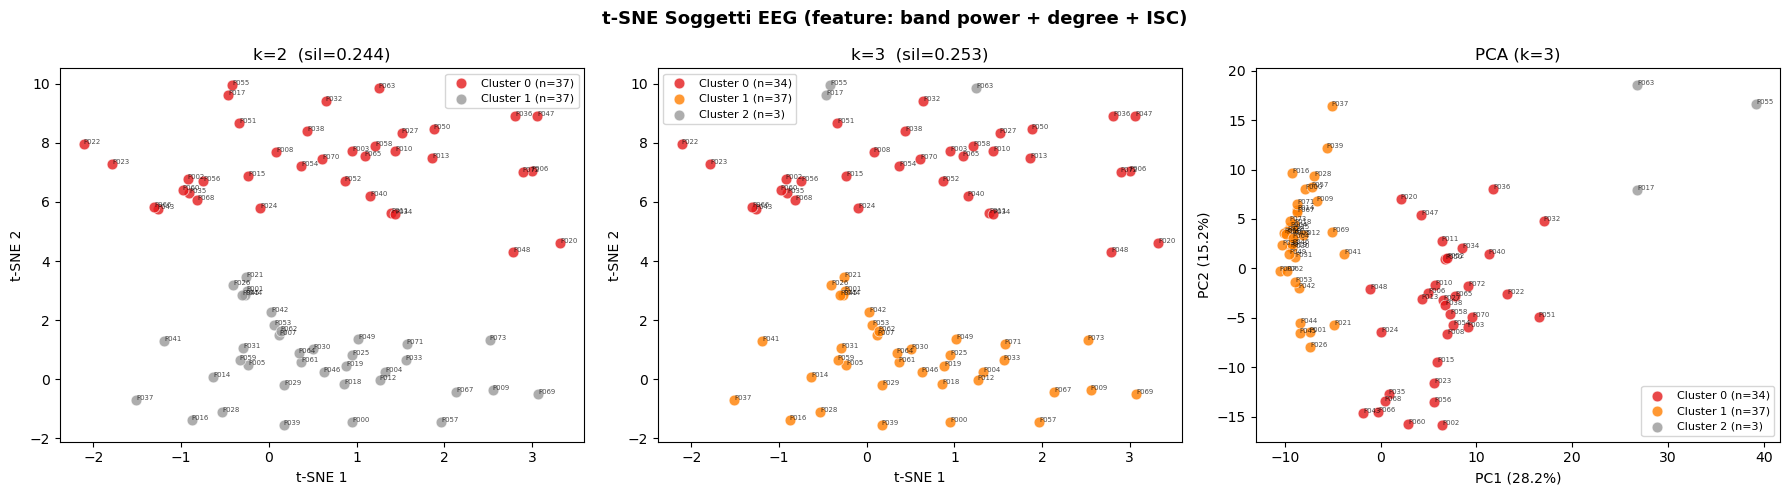

17:20:25  INFO      Salvato eeg08c_clusters_tsne.png


In [9]:
# t-SNE
perp = min(30, N_SUBJ // 3)
tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=2000)
FEAT_2D = tsne.fit_transform(FEAT_PCA)   # (N, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE Soggetti EEG (feature: band power + degree + ISC)',
             fontsize=13, fontweight='bold')

cmap2 = cm.get_cmap('Set1', 2)
cmap3 = cm.get_cmap('Set1', 3)

for ax, k, cmap in zip(axes[:2], [2, 3], [cmap2, cmap3]):
    labs = LABELS[k]
    for c in range(k):
        mask = labs == c
        ax.scatter(FEAT_2D[mask, 0], FEAT_2D[mask, 1],
                   c=[cmap(c)], s=60, alpha=0.8, edgecolors='white', lw=0.5,
                   label=f'Cluster {c} (n={mask.sum()})')
    for i, sid in enumerate(SUBJ_IDS):
        ax.annotate(f'P{sid:03d}', FEAT_2D[i], fontsize=5, alpha=0.7)
    ax.set_title(f'k={k}  (sil={sil_scores[k]:.3f})')
    ax.legend(fontsize=8, loc='best')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

# PCA 2D (PC1 vs PC2) come alternativa
ax = axes[2]
for c in range(BEST_K):
    mask = LABELS[BEST_K] == c
    ax.scatter(FEAT_PCA[mask, 0], FEAT_PCA[mask, 1],
               c=[cm.get_cmap('Set1', BEST_K)(c)], s=60, alpha=0.8,
               edgecolors='white', lw=0.5,
               label=f'Cluster {c} (n={mask.sum()})')
for i, sid in enumerate(SUBJ_IDS):
    ax.annotate(f'P{sid:03d}', (FEAT_PCA[i, 0], FEAT_PCA[i, 1]), fontsize=5, alpha=0.7)
var1 = pca.explained_variance_ratio_[0]*100
var2 = pca.explained_variance_ratio_[1]*100
ax.set_xlabel(f'PC1 ({var1:.1f}%)')
ax.set_ylabel(f'PC2 ({var2:.1f}%)')
ax.set_title(f'PCA (k={BEST_K})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg08c_clusters_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Salvato eeg08c_clusters_tsne.png')

## §8 — Post-Hoc: Overlay EEG_08b Accuracy

Carica ranking da EEG_08b (opzionale), overlay accuracy sul t-SNE.  
**Questo e' VALIDAZIONE, non definizione dei cluster.**

17:20:26  INFO      Ranking EEG_08b caricato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08b_subject_ranking.csv  (74 righe)
/tmp/ipykernel_352607/997725858.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[f'Cluster {c}\n(n={len(cluster_accs[c])})'
/tmp/ipykernel_352607/997725858.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = cm.get_cmap('Set1', BEST_K)


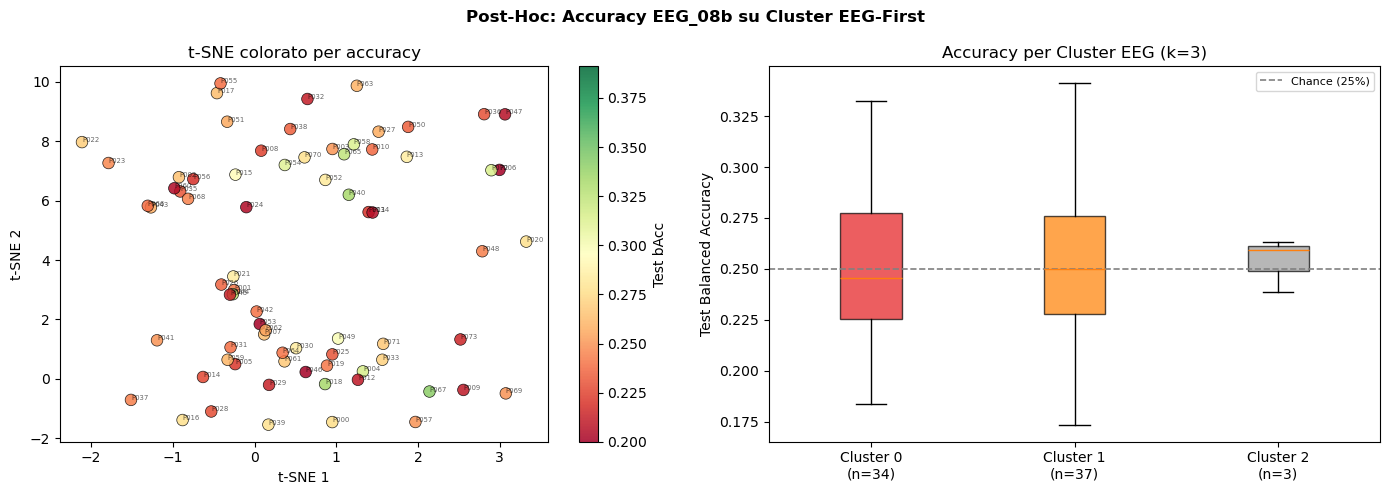

17:20:27  INFO      Salvato eeg08c_posthoc_accuracy.png


In [10]:
# Cerca ranking CSV (EEG_08b)
ranking_paths = [
    FIG_DIR / 'eeg08b_subject_ranking.csv',
    FIG_DIR / 'eeg08b_ranking_top1.csv',
]
df_08b = None
for rp in ranking_paths:
    if rp.exists():
        df_08b = pd.read_csv(rp)
        log.info(f'Ranking EEG_08b caricato: {rp}  ({len(df_08b)} righe)')
        break

if df_08b is None:
    log.warning('EEG_08b ranking non trovato — skip post-hoc. Riesegui EEG_08b per abilitarlo.')
    print('[INFO] Post-hoc accuracy overlay saltato: nessun file eeg08b_subject_ranking.csv.')
else:
    # parse subject ID numerico
    id_col = 'Subject' if 'Subject' in df_08b.columns else df_08b.columns[0]
    acc_col = 'Test bAcc' if 'Test bAcc' in df_08b.columns else df_08b.columns[1]
    df_08b['subj_id'] = df_08b[id_col].str[1:].astype(int)

    # allinea con SUBJ_IDS correnti
    sid2acc = df_08b.set_index('subj_id')[acc_col].to_dict()
    accs = np.array([sid2acc.get(s, np.nan) for s in SUBJ_IDS])
    valid_mask = ~np.isnan(accs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Post-Hoc: Accuracy EEG_08b su Cluster EEG-First',
                 fontsize=12, fontweight='bold')

    # left: t-SNE colorato per accuracy
    ax = axes[0]
    sc = ax.scatter(FEAT_2D[valid_mask, 0], FEAT_2D[valid_mask, 1],
                    c=accs[valid_mask], cmap='RdYlGn',
                    vmin=0.20, vmax=min(accs[valid_mask].max()+0.05, 0.70),
                    s=70, edgecolors='black', lw=0.5, alpha=0.85)
    plt.colorbar(sc, ax=ax, label='Test bAcc')
    for i, sid in enumerate(SUBJ_IDS):
        if valid_mask[i]:
            ax.annotate(f'P{sid:03d}', FEAT_2D[i], fontsize=5, alpha=0.6)
    ax.set_title('t-SNE colorato per accuracy'); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

    # right: boxplot accuracy per cluster
    ax = axes[1]
    cluster_accs = defaultdict(list)
    labs = LABELS[BEST_K]
    for i in range(N_SUBJ):
        if valid_mask[i]:
            cluster_accs[labs[i]].append(accs[i])
    data_box = [cluster_accs[c] for c in sorted(cluster_accs.keys())]
    bp = ax.boxplot(data_box, labels=[f'Cluster {c}\n(n={len(cluster_accs[c])})'
                                       for c in sorted(cluster_accs.keys())],
                    patch_artist=True)
    cmap_k = cm.get_cmap('Set1', BEST_K)
    for patch, c in zip(bp['boxes'], sorted(cluster_accs.keys())):
        patch.set_facecolor(cmap_k(c)); patch.set_alpha(0.7)
    ax.axhline(0.25, color='gray', ls='--', lw=1.2, label='Chance (25%)')
    ax.set_ylabel('Test Balanced Accuracy')
    ax.set_title(f'Accuracy per Cluster EEG (k={BEST_K})')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg08c_posthoc_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    log.info('Salvato eeg08c_posthoc_accuracy.png')


## §9 — Test Statistico: Cluster vs Accuracy

Kruskal-Wallis: i cluster EEG hanno distribuzioni di accuracy diverse?

In [11]:
if df_08b is None:
    print('[INFO] EEG_08b ranking non disponibile — skip test statistico.')
else:
    # Kruskal-Wallis tra cluster
    groups = [cluster_accs[c] for c in sorted(cluster_accs.keys())]
    if all(len(g) >= 3 for g in groups):
        stat, pval = kruskal(*groups)
        log.info(f'Kruskal-Wallis: H={stat:.4f}  p={pval:.4f}')
        print(f'Kruskal-Wallis (cluster vs accuracy): H={stat:.4f}, p={pval:.4f}')
        if pval < 0.05:
            print('  -> SIGNIFICATIVO: i cluster EEG separano soggetti con accuracy diversa.')
        else:
            print('  -> Non significativo: accuracy simile tra cluster (ma clustering EEG valido per se).')
    else:
        print('[INFO] Troppo pochi soggetti per cluster per test statistico.')

    # Spearman: ISC vs accuracy
    isc_vec = FEAT_MATRIX[:, -1]  # ultima colonna = ISC
    paired = [(isc_vec[i], accs[i]) for i in range(N_SUBJ)
              if valid_mask[i] and not np.isnan(isc_vec[i])]
    if len(paired) >= 5:
        x_isc, y_acc = zip(*paired)
        r, p = spearmanr(x_isc, y_acc)
        print(f'Spearman ISC vs accuracy: r={r:+.3f}  p={p:.4f}')

    # Cluster membership summary
    print(f'\nCluster membership (k={BEST_K}):')
    labs_best = LABELS[BEST_K]
    for c in range(BEST_K):
        members = [f'P{SUBJ_IDS[i]:03d}' for i in range(N_SUBJ) if labs_best[i] == c]
        acc_c   = [accs[i] for i in range(N_SUBJ) if labs_best[i] == c and valid_mask[i]]
        print(f'  Cluster {c} (n={len(members)}):')
        print(f'    Soggetti: {members[:10]}{"..." if len(members)>10 else ""}')
        if acc_c:
            print(f'    Accuracy: mean={np.mean(acc_c):.4f}  std={np.std(acc_c):.4f}  min={np.min(acc_c):.4f}  max={np.max(acc_c):.4f}')

    # salva summary CSV
    df_summary = pd.DataFrame({
        'subj_id':  SUBJ_IDS,
        'cluster_k2': LABELS[2],
        'cluster_k3': LABELS[3],
        f'cluster_k{BEST_K}_best': LABELS[BEST_K],
        'test_bacc': accs,
    })
    df_summary['subject'] = df_summary['subj_id'].map(lambda x: f'P{x:03d}')
    out_csv = FIG_DIR / 'eeg08c_subject_clusters.csv'
    df_summary.to_csv(out_csv, index=False)
    log.info(f'Salvato: {out_csv}')
    print(f'\nCSV salvato: {out_csv}')


17:20:28  INFO      Kruskal-Wallis: H=0.1250  p=0.9394
17:20:28  INFO      Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08c_subject_clusters.csv


Kruskal-Wallis (cluster vs accuracy): H=0.1250, p=0.9394
  -> Non significativo: accuracy simile tra cluster (ma clustering EEG valido per se).
Spearman ISC vs accuracy: r=+0.055  p=0.6425

Cluster membership (k=3):
  Cluster 0 (n=34):
    Soggetti: ['P002', 'P003', 'P006', 'P008', 'P010', 'P011', 'P013', 'P015', 'P020', 'P022']...
    Accuracy: mean=0.2523  std=0.0378  min=0.1835  max=0.3323
  Cluster 1 (n=37):
    Soggetti: ['P000', 'P001', 'P004', 'P005', 'P007', 'P009', 'P012', 'P014', 'P016', 'P018']...
    Accuracy: mean=0.2532  std=0.0374  min=0.1735  max=0.3411
  Cluster 2 (n=3):
    Soggetti: ['P017', 'P055', 'P063']
    Accuracy: mean=0.2537  std=0.0107  min=0.2388  max=0.2631

CSV salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg08c_subject_clusters.csv
